# HDCCA empirical application on CRSP daily stock data

This notebook builds the main empirical application for my Bachelor Thesis
“High Dimensional Canonical Correlation Analysis: Applications to Financial Data”

The data used is **CRSP daily stock data** : https://wrds-www.wharton.upenn.edu/pages/about/data-vendors/center-for-research-in-security-prices-crsp/ 

The workflow followed is:

1. build two large equity panels (cyclical vs defensive stocks),
2. estimate classical CCA window by window,
3. compare the empirical spectrum to the HDCCA bulk edge,
4. study outliers, eigengaps, split-sample vector stability, top-\(k\) subspace stability, and held-out roots,
5. export of figures and tables.

Other design choices include:
- **Sector mapping:** an **FF12-inspired SIC mapping** is used to create a transparent cyclical/defensive split from CRSP SIC codes
- **Frequency:** daily returns are compounded to **weekly** returns

## 1. Configuration

In [ ]:
# ---- import libraries 
import re
from pathlib import Path
import warnings
import math
import csv
import io
import zipfile
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

try:
    from tqdm.auto import tqdm
except Exception:
    def tqdm(x, **kwargs):
        return x

warnings.filterwarnings("ignore", category=RuntimeWarning)
pd.set_option("display.max_columns", 300)
pd.set_option("display.width", 220)

In [ ]:
# ---- style settings 
THESIS_COLORS = {
    "navy": "#0B1F3A",
    "blue": "#1D4E89",
    "teal": "#0E7490",
    "green": "#2F6B3B",
    "burgundy": "#7A1F3D",
    "gold": "#A06A00",
    "charcoal": "#111111",
}

mpl.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "savefig.bbox": "tight",
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "Nimbus Roman", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "axes.edgecolor": "black",
    "axes.labelcolor": "black",
    "axes.titlecolor": "black",
    "axes.linewidth": 1.2,
    "xtick.color": "black",
    "ytick.color": "black",
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "axes.grid": False,
    "legend.frameon": True,
    "legend.facecolor": "white",
    "legend.edgecolor": "black",
    "legend.framealpha": 1.0,
    "figure.dpi": 140,
    "savefig.dpi": 300,
})

def thesis_figure(figsize=(9, 5)):
    fig, ax = plt.subplots(figsize=figsize, facecolor="white", constrained_layout=True)
    ax.set_facecolor("white")
    return fig, ax

def thesis_subplots(nrows, ncols, figsize=(9, 5), sharex=False, sharey=False):
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=figsize,
        facecolor="white",
        constrained_layout=True,
        sharex=sharex,
        sharey=sharey,
    )
    axes_array = np.atleast_1d(axes).ravel()
    for ax in axes_array:
        ax.set_facecolor("white")
    return fig, axes

def style_axes(ax):
    for spine in ax.spines.values():
        spine.set_color("black")
        spine.set_linewidth(1.2)
    ax.tick_params(axis="both", colors="black", width=1.0, labelsize=11)
    ax.xaxis.label.set_size(12)
    ax.yaxis.label.set_size(12)
    ax.title.set_size(13)
    return ax

def outside_legend(ax, ncol=1):
    handles, labels = ax.get_legend_handles_labels()
    if handles:
        ax.legend(
            loc="upper left",
            bbox_to_anchor=(1.02, 1.0),
            borderaxespad=0.0,
            ncol=ncol,
            fontsize=10,
        )

def rotate_xlabels(ax, rotation=35):
    for label in ax.get_xticklabels():
        label.set_rotation(rotation)
        label.set_ha("right")

In [ ]:
# ---- define paths and constants
BASE_DIR = Path.cwd()
CRSP_ZIP = BASE_DIR / "crsp_dataset.zip"

OUTPUT_DIR = BASE_DIR / "empirical_outputs_crsp"
FIG_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
DATA_DIR = OUTPUT_DIR / "clean_data"
OUTPUT_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)
TABLE_DIR.mkdir(exist_ok=True)
DATA_DIR.mkdir(exist_ok=True)

RETURNS_FILE = DATA_DIR / "returns_weekly_clean_crsp.csv"
META_FILE = DATA_DIR / "stock_metadata_clean_crsp.csv"
WEEKLY_LONG_FILE = DATA_DIR / "weekly_long_selected_universe_crsp.csv"

RIDGE_EPS = 1e-10
SEED = 42

# ---- universe construction 
TARGET_PANEL_SIZE = 80    # target size per side
MIN_PANEL_SIZE = 20       # fail-safe lower bound in case coverage is weaker than expected
PRESELECTION_SIZE = 200
WEEK_FREQ = "W-FRI"
COVERAGE_GRID = [0.99, 0.97, 0.95, 0.92, 0.90, 0.87, 0.85, 0.80, 0.75, 0.70]
REQUIRE_US_INCORP = True
REQUIRE_SECURITYTYPE_EQTY = True
REQUIRE_SECURITYSUBTYPE_COM = True
REQUIRE_SHARETYPE_COM = False   

# ---- rolling empirical specifications
FAST_MODE = False
ANALYSIS_SPECS = [
    {"label": "main_260w", "window": 260, "step": 4, "n_perm": 1000 if not FAST_MODE else 250, "sample": "full"},
    {"label": "robust_208w", "window": 208, "step": 4, "n_perm": 500 if not FAST_MODE else 125, "sample": "full"},
    {"label": "robust_364w", "window": 364, "step": 4, "n_perm": 500 if not FAST_MODE else 125, "sample": "full"},
    {"label": "pre2020_260w", "window": 260, "step": 4, "n_perm": 500 if not FAST_MODE else 125, "sample": "pre2020"},
    {"label": "post2020_260w", "window": 260, "step": 4, "n_perm": 500 if not FAST_MODE else 125, "sample": "post2020"},
]
PRE2020_END = pd.Timestamp("2020-01-03")
POST2020_START = pd.Timestamp("2020-01-10")
SUBSPACE_KS = [1, 2, 3, 5]
N_COMPONENT_VECTOR_STAB = 5

if not CRSP_ZIP.exists():
    raise FileNotFoundError(f"Expected {CRSP_ZIP} to exist. Put crsp_dataset.zip in the notebook working folder.")

print("Base directory:", BASE_DIR)
print("CRSP zip:", CRSP_ZIP)
print("Output directory:", OUTPUT_DIR)

Base directory: /Users/albatorres/Desktop/UC3M/TFG Econ./CRSP_Analysis
CRSP zip: /Users/albatorres/Desktop/UC3M/TFG Econ./CRSP_Analysis/crsp_dataset.zip
Output directory: /Users/albatorres/Desktop/UC3M/TFG Econ./CRSP_Analysis/empirical_outputs_crsp


## 2. Load CRSP

In [ ]:
# Column aliases are handled so the notebook remains robust to minor export-name differences
COLUMN_ALIASES = {
    "permno": ["permno"],
    "permco": ["permco"],
    "date": ["dlycaldt", "date", "caldt", "dailycalendardate"],
    "ret": ["dlyret", "ret", "dailytotalreturn"],
    "retx": ["dlyretx", "retx", "dailypricereturn"],
    "prc": ["dlyprc", "prc", "dailyprice"],
    "shrout": ["shrout", "sharesoutstanding"],
    "siccd": ["siccd", "siccode"],
    "primaryexch": ["primaryexch", "primexch", "primaryexchange"],
    "securitytype": ["securitytype"],
    "securitysubtype": ["securitysubtype"],
    "sharetype": ["sharetype"],
    "usincflg": ["usincflg", "usincflag"],
    "tradingstatusflg": ["tradingstatusflg", "tradingstatusflag"],
    "delflg": ["dlydelflg", "delflg", "dailydelistingflag"],
    "comnam": ["comnam", "companyname", "issuername"],
    "ticker": ["ticker", "tickersymbol"],
}

REQUIRED_CANONICAL = ["permno", "date", "ret", "prc", "shrout", "siccd"]
OPTIONAL_CANONICAL = ["permco", "primaryexch", "securitytype", "securitysubtype", "sharetype",
                      "usincflg", "tradingstatusflg", "delflg", "retx", "comnam", "ticker"]

def normalize_name(x):
    return re.sub(r"[^a-z0-9]", "", str(x).strip().lower())

def detect_member_and_sep(zip_path):
    with zipfile.ZipFile(zip_path) as zf:
        members = [zi for zi in zf.infolist() if not zi.is_dir()]
        if not members:
            raise ValueError("Zip archive contains no files.")
        candidates = [m for m in members if Path(m.filename).suffix.lower() in {".csv", ".txt", ".tsv", ".dat"}]
        if not candidates:
            candidates = members
        member = max(candidates, key=lambda z: z.file_size)
        with zf.open(member.filename) as fh:
            sample = fh.read(65536).decode("utf-8", errors="ignore")
        try:
            sep = csv.Sniffer().sniff(sample, delimiters=",\t;|").delimiter
        except Exception:
            sep = ","
    return member.filename, sep

def discover_columns(zip_path, member, sep):
    with zipfile.ZipFile(zip_path) as zf:
        with zf.open(member) as fh:
            header_df = pd.read_csv(fh, sep=sep, nrows=0, low_memory=False)
    original_cols = list(header_df.columns)
    norm_map = {normalize_name(c): c for c in original_cols}
    chosen = {}
    for canon_name, aliases in COLUMN_ALIASES.items():
        for alias in aliases:
            alias_norm = normalize_name(alias)
            if alias_norm in norm_map:
                chosen[canon_name] = norm_map[alias_norm]
                break
    missing = [c for c in REQUIRED_CANONICAL if c not in chosen]
    if missing:
        raise ValueError(f"Could not match required columns in the zip export: {missing}. Available columns: {original_cols[:40]}")
    return chosen, original_cols

member_name, inferred_sep = detect_member_and_sep(CRSP_ZIP)
chosen_columns, all_columns = discover_columns(CRSP_ZIP, member_name, inferred_sep)

print("Selected archive member:", member_name)
print("Detected separator:", repr(inferred_sep))
print("Matched columns:")
display(pd.Series(chosen_columns).sort_index())

usecols_original = list(dict.fromkeys(chosen_columns.values()))

Selected archive member: b3qjpiipqiqukkp6.csv
Detected separator: ','
Matched columns:


date                        DlyCalDt
delflg                     DlyDelFlg
permco                        PERMCO
permno                        PERMNO
prc                           DlyPrc
primaryexch              PrimaryExch
ret                           DlyRet
retx                         DlyRetx
securitysubtype      SecuritySubType
securitytype            SecurityType
sharetype                  ShareType
shrout                        ShrOut
siccd                          SICCD
ticker                        Ticker
tradingstatusflg    TradingStatusFlg
usincflg                    USIncFlg
dtype: object

*The final balanced panel is obtained after a two-stage selection procedure. 
First, a large-cap shortlist of 200 securities per side is formed. 
Second, a coverage filter is applied and the largest names are retained subject to complete 
weekly coverage. The selected specification uses a 99 percentage coverage threshold, 
which allows the construction of a balanced 80-by-80 weekly panel with no missing returns 
over the retained sample.*

## 3. First pass: filter the CRSP universe and preselect candidate securities

In [ ]:
def ff12_from_sic(sic):
    if pd.isna(sic):
        return None
    try:
        sic = int(sic)
    except Exception:
        return None

    if ((100 <= sic <= 999) or (2000 <= sic <= 2399) or (2700 <= sic <= 2749) or
        (2770 <= sic <= 2799) or (3100 <= sic <= 3199) or (3940 <= sic <= 3989)):
        return "nodur"
    if ((2500 <= sic <= 2519) or (2590 <= sic <= 2599) or (3630 <= sic <= 3659) or
        (3710 <= sic <= 3711) or sic in {3714, 3716} or (3750 <= sic <= 3751) or
        sic == 3792 or (3900 <= sic <= 3939) or (3990 <= sic <= 3999)):
        return "durbl"
    if ((2520 <= sic <= 2589) or (2600 <= sic <= 2699) or (2750 <= sic <= 2769) or
        (3000 <= sic <= 3099) or (3200 <= sic <= 3569) or (3580 <= sic <= 3629) or
        (3700 <= sic <= 3709) or (3712 <= sic <= 3713) or sic == 3715 or
        (3717 <= sic <= 3749) or (3752 <= sic <= 3791) or (3793 <= sic <= 3799) or
        (3830 <= sic <= 3839) or (3860 <= sic <= 3899)):
        return "manuf"
    if ((1200 <= sic <= 1399) or (2900 <= sic <= 2999)):
        return "enrgy"
    if ((2800 <= sic <= 2829) or (2840 <= sic <= 2899)):
        return "chems"
    if ((3570 <= sic <= 3579) or (3660 <= sic <= 3692) or (3694 <= sic <= 3699) or
        (3810 <= sic <= 3829) or (7370 <= sic <= 7379)):
        return "buseq"
    if (4800 <= sic <= 4899):
        return "telcm"
    if (4900 <= sic <= 4949):
        return "utils"
    if ((5000 <= sic <= 5999) or (7200 <= sic <= 7299) or (7600 <= sic <= 7699)):
        return "shops"
    if ((2830 <= sic <= 2839) or sic == 3693 or (3840 <= sic <= 3859) or (8000 <= sic <= 8099)):
        return "hlth"
    if (6000 <= sic <= 6999):
        return "money"
    return "other"

In [ ]:
# ----- mapping:
# cyclical = durables/manufacturing/energy/chemicals/retail-services ("shops")
CYCLICAL_FF12 = {"durbl", "manuf", "enrgy", "chems", "shops"}
# defensive = non-durables (consumer staples), health, telecom, utilities
DEFENSIVE_FF12 = {"nodur", "hlth", "telcm", "utils"}

In [ ]:
def bucket_from_ff12(sector):
    if sector in CYCLICAL_FF12:
        return "cyclical"
    if sector in DEFENSIVE_FF12:
        return "defensive"
    return None

def standardize_chunk(chunk):
    rename_map = {v: k for k, v in chosen_columns.items()}
    chunk = chunk.rename(columns=rename_map).copy()

    for col in ["permno", "permco", "siccd"]:
        if col in chunk.columns:
            chunk[col] = pd.to_numeric(chunk[col], errors="coerce")

    chunk["date"] = pd.to_datetime(chunk["date"], errors="coerce")
    for col in ["ret", "retx", "prc", "shrout"]:
        if col in chunk.columns:
            chunk[col] = pd.to_numeric(chunk[col], errors="coerce")

    for col in ["primaryexch", "securitytype", "securitysubtype", "sharetype", "usincflg", "tradingstatusflg", "delflg", "comnam", "ticker"]:
        if col in chunk.columns:
            chunk[col] = chunk[col].astype(str).str.strip()

    return chunk

def filter_universe(chunk):
    mask = chunk["permno"].notna() & chunk["date"].notna()

    if REQUIRE_US_INCORP and "usincflg" in chunk.columns:
        mask &= chunk["usincflg"].str.upper().eq("Y")
    if REQUIRE_SECURITYTYPE_EQTY and "securitytype" in chunk.columns:
        mask &= chunk["securitytype"].str.upper().eq("EQTY")
    if REQUIRE_SECURITYSUBTYPE_COM and "securitysubtype" in chunk.columns:
        mask &= chunk["securitysubtype"].str.upper().eq("COM")
    if REQUIRE_SHARETYPE_COM and "sharetype" in chunk.columns:
        mask &= chunk["sharetype"].str.upper().eq("COM")

    chunk = chunk.loc[mask].copy()
    chunk["ff12_sector"] = chunk["siccd"].map(ff12_from_sic)
    chunk["bucket"] = chunk["ff12_sector"].map(bucket_from_ff12)
    chunk = chunk.loc[chunk["bucket"].isin(["cyclical", "defensive"])].copy()

    chunk["mcap"] = chunk["prc"].abs() * chunk["shrout"]
    chunk = chunk.loc[chunk["ret"].notna()].copy()
    return chunk

candidate_stats = {}

In [ ]:
with zipfile.ZipFile(CRSP_ZIP) as zf:
    with zf.open(member_name) as fh:
        reader = pd.read_csv(fh, sep=inferred_sep, usecols=usecols_original, chunksize=1_000_000, low_memory=False)
        for chunk in tqdm(reader, desc="Pass 1: screening CRSP universe"):
            chunk = standardize_chunk(chunk)
            chunk = filter_universe(chunk)
            if chunk.empty:
                continue

            agg_dict = {
                "date": ["min", "max"],
                "ret": ["count"],
                "mcap": ["sum", "count"],
                "bucket": ["first"],
                "ff12_sector": ["first"],
            }
            if "permco" in chunk.columns:
                agg_dict["permco"] = ["first"]
            if "primaryexch" in chunk.columns:
                agg_dict["primaryexch"] = ["first"]
            if "comnam" in chunk.columns:
                agg_dict["comnam"] = ["first"]
            if "ticker" in chunk.columns:
                agg_dict["ticker"] = ["first"]

            grouped = chunk.groupby("permno", observed=True).agg(agg_dict)
            grouped.columns = ["_".join([a, b]).strip("_") for a, b in grouped.columns]
            grouped = grouped.reset_index()

            for row in grouped.itertuples(index=False):
                permno = int(row.permno)
                rec = candidate_stats.get(permno, {
                    "permno": permno,
                    "permco": np.nan,
                    "bucket": None,
                    "ff12_sector": None,
                    "primaryexch": None,
                    "comnam": None,
                    "ticker": None,
                    "first_date": pd.Timestamp.max,
                    "last_date": pd.Timestamp.min,
                    "n_ret_obs": 0,
                    "mcap_sum": 0.0,
                    "mcap_n": 0,
                })
                rec["first_date"] = min(rec["first_date"], getattr(row, "date_min"))
                rec["last_date"] = max(rec["last_date"], getattr(row, "date_max"))
                rec["n_ret_obs"] += int(getattr(row, "ret_count"))
                rec["mcap_sum"] += float(getattr(row, "mcap_sum")) if pd.notna(getattr(row, "mcap_sum")) else 0.0
                rec["mcap_n"] += int(getattr(row, "mcap_count"))
                for field in ["permco", "bucket", "ff12_sector", "primaryexch", "comnam", "ticker"]:
                    attr_name = f"{field}_first"
                    if hasattr(row, attr_name):
                        val = getattr(row, attr_name)
                        if rec.get(field) is None or (isinstance(rec.get(field), float) and pd.isna(rec.get(field))) or rec.get(field) == "nan":
                            rec[field] = val
                candidate_stats[permno] = rec

In [ ]:
candidate_df = pd.DataFrame(candidate_stats.values()).sort_values(["bucket", "mcap_sum"], ascending=[True, False])
candidate_df["avg_mcap"] = candidate_df["mcap_sum"] / candidate_df["mcap_n"].replace(0, np.nan)
candidate_df["first_date"] = pd.to_datetime(candidate_df["first_date"])
candidate_df["last_date"] = pd.to_datetime(candidate_df["last_date"])

sample_start = candidate_df["first_date"].min().normalize()
sample_end = candidate_df["last_date"].max().normalize()
sample_span_days = max((sample_end - sample_start).days, 1)

candidate_df["span_ratio"] = (candidate_df["last_date"] - candidate_df["first_date"]).dt.days / sample_span_days
candidate_df["eligible_preselect"] = candidate_df["span_ratio"] >= 0.80

preselected = (
    candidate_df.loc[candidate_df["eligible_preselect"]]
    .sort_values(["bucket", "avg_mcap"], ascending=[True, False])
    .groupby("bucket", group_keys=False)
    .head(PRESELECTION_SIZE)
    .copy()
)

In [ ]:
# fail-safe check :
bucket_counts_pre = preselected["bucket"].value_counts().to_dict()
for bucket in ["cyclical", "defensive"]:
    if bucket_counts_pre.get(bucket, 0) < max(MIN_PANEL_SIZE, PRESELECTION_SIZE // 4):
        top_fallback = (
            candidate_df.loc[candidate_df["bucket"] == bucket]
            .sort_values("avg_mcap", ascending=False)
            .head(PRESELECTION_SIZE)
            .copy()
        )
        preselected = pd.concat([preselected.loc[preselected["bucket"] != bucket], top_fallback], ignore_index=True)

preselected = preselected.drop_duplicates(subset="permno").copy()
preselected_permnos = set(preselected["permno"].astype(int))

preselection_summary = (
    preselected.groupby("bucket")
    .agg(
        n_permnos=("permno", "nunique"),
        median_avg_mcap=("avg_mcap", "median"),
        median_span_ratio=("span_ratio", "median"),
    )
    .reset_index()
)
display(preselection_summary)
preselection_summary.to_csv(TABLE_DIR / "crsp_preselection_summary.csv", index=False)
candidate_df.to_csv(TABLE_DIR / "crsp_candidate_security_stats.csv", index=False)

,bucket,n_permnos,median_avg_mcap,median_span_ratio
0,cyclical,200,1.107476e+07,1.0
1,defensive,200,8.798904e+06,1.0


## 4. Second pass: build weekly returns for the shortlisted securities

In [ ]:
daily_selected_parts = []

with zipfile.ZipFile(CRSP_ZIP) as zf:
    with zf.open(member_name) as fh:
        reader = pd.read_csv(fh, sep=inferred_sep, usecols=usecols_original, chunksize=1_000_000, low_memory=False)
        for chunk in tqdm(reader, desc="Pass 2: loading shortlisted securities"):
            chunk = standardize_chunk(chunk)
            chunk = filter_universe(chunk)
            if chunk.empty:
                continue
            chunk = chunk.loc[chunk["permno"].astype("Int64").isin(preselected_permnos)].copy()
            if chunk.empty:
                continue
            daily_selected_parts.append(chunk)

if not daily_selected_parts:
    raise ValueError("No rows survived the preselection + filtering step. Recheck the CRSP export and filters.")

daily_selected = pd.concat(daily_selected_parts, ignore_index=True)
daily_selected["permno"] = daily_selected["permno"].astype(int)
daily_selected["week_end"] = daily_selected["date"].dt.to_period(WEEK_FREQ).dt.end_time.dt.normalize()

In [ ]:
# remove duplicate permno-date rows if the export has any
daily_selected = (
    daily_selected.sort_values(["permno", "date"])
    .drop_duplicates(subset=["permno", "date"], keep="last")
    .copy()
)

In [ ]:
def compound_return(x):
    x = pd.to_numeric(x, errors="coerce").dropna()
    if x.empty:
        return np.nan
    return float(np.prod(1.0 + x.to_numpy(dtype=float)) - 1.0)

def last_valid(x):
    x = x.dropna()
    if x.empty:
        return np.nan
    return x.iloc[-1]

weekly_long = (
    daily_selected
    .sort_values(["permno", "date"])
    .groupby(["permno", "week_end"], observed=True)
    .agg(
        ret_weekly=("ret", compound_return),
        mcap_weekly=("mcap", last_valid),
        bucket=("bucket", "last"),
        ff12_sector=("ff12_sector", "last"),
        siccd=("siccd", "last"),
        permco=("permco", "last") if "permco" in daily_selected.columns else ("permno", "last"),
        primaryexch=("primaryexch", "last") if "primaryexch" in daily_selected.columns else ("permno", "last"),
        comnam=("comnam", "last") if "comnam" in daily_selected.columns else ("permno", "last"),
        ticker=("ticker", "last") if "ticker" in daily_selected.columns else ("permno", "last"),
    )
    .reset_index()
)

weekly_long["permno"] = weekly_long["permno"].astype(int)
weekly_long["week_end"] = pd.to_datetime(weekly_long["week_end"])
weekly_long.to_csv(WEEKLY_LONG_FILE, index=False)

all_weeks = pd.date_range(weekly_long["week_end"].min(), weekly_long["week_end"].max(), freq=WEEK_FREQ)
n_total_weeks = len(all_weeks)

In [ ]:
weekly_stats = (
    weekly_long.groupby("permno", observed=True)
    .agg(
        bucket=("bucket", "last"),
        ff12_sector=("ff12_sector", "last"),
        permco=("permco", "last"),
        primaryexch=("primaryexch", "last"),
        comnam=("comnam", "last"),
        ticker=("ticker", "last"),
        first_week=("week_end", "min"),
        last_week=("week_end", "max"),
        n_weeks=("ret_weekly", lambda s: s.notna().sum()),
        avg_mcap=("mcap_weekly", "mean"),
        median_mcap=("mcap_weekly", "median"),
    )
    .reset_index()
)
weekly_stats["coverage"] = weekly_stats["n_weeks"] / n_total_weeks
weekly_stats = weekly_stats.sort_values(["bucket", "avg_mcap"], ascending=[True, False]).copy()

In [ ]:
selection_trials = []
best_payload = None

for thr in COVERAGE_GRID:
    cyc = weekly_stats.loc[(weekly_stats["bucket"] == "cyclical") & (weekly_stats["coverage"] >= thr)].sort_values("avg_mcap", ascending=False)
    dfn = weekly_stats.loc[(weekly_stats["bucket"] == "defensive") & (weekly_stats["coverage"] >= thr)].sort_values("avg_mcap", ascending=False)
    size = min(TARGET_PANEL_SIZE, len(cyc), len(dfn))
    if size < MIN_PANEL_SIZE:
        selection_trials.append({"coverage_threshold": thr, "size_per_bucket": size, "complete_weeks_after_dropna": 0})
        continue

    selected_permnos = pd.concat([cyc.head(size), dfn.head(size)], ignore_index=True)["permno"].astype(int).tolist()
    wide_trial = weekly_long.pivot(index="week_end", columns="permno", values="ret_weekly").sort_index()
    wide_trial = wide_trial[selected_permnos].dropna(how="any")
    n_complete_weeks = len(wide_trial)

    selection_trials.append({
        "coverage_threshold": thr,
        "size_per_bucket": size,
        "complete_weeks_after_dropna": n_complete_weeks,
    })

    payload = {
        "threshold": thr,
        "size": size,
        "selected_permnos": selected_permnos,
        "wide": wide_trial,
    }

    if best_payload is None:
        best_payload = payload
    else:
        old = (best_payload["size"], len(best_payload["wide"]), best_payload["threshold"])
        new = (payload["size"], len(payload["wide"]), payload["threshold"])
        if new > old:
            best_payload = payload

In [ ]:
selection_trials = pd.DataFrame(selection_trials)
display(selection_trials)
selection_trials.to_csv(TABLE_DIR / "crsp_selection_trials.csv", index=False)

if best_payload is None:
    raise ValueError("Could not build a balanced cyclical/defensive panel from the CRSP extract.")

selected_permnos = set(best_payload["selected_permnos"])
ret_wide = best_payload["wide"].copy()

selected_meta = (
    weekly_stats.loc[weekly_stats["permno"].isin(selected_permnos)]
    .copy()
    .sort_values(["bucket", "avg_mcap"], ascending=[True, False])
)
selected_meta["security_id"] = selected_meta["permno"].astype(int).astype(str)

ret_wide.columns = ret_wide.columns.astype(int).astype(str)
ret_wide.index.name = "Date"

In [ ]:
meta_out = selected_meta[[
    "security_id", "permno", "permco", "ticker", "comnam", "primaryexch",
    "siccd" if "siccd" in selected_meta.columns else "permno",
    "ff12_sector", "bucket", "coverage", "avg_mcap", "median_mcap", "first_week", "last_week"
]].copy() if "siccd" in selected_meta.columns else selected_meta[[
    "security_id", "permno", "permco", "ticker", "comnam", "primaryexch",
    "ff12_sector", "bucket", "coverage", "avg_mcap", "median_mcap", "first_week", "last_week"
]].copy()

In [ ]:
# ensure a SIC column exists in metadata by merging from weekly_long if needed
if "siccd" not in meta_out.columns:
    sic_map = weekly_long.groupby("permno")["siccd"].last()
    meta_out["siccd"] = meta_out["permno"].map(sic_map)

ret_wide.to_csv(RETURNS_FILE)
meta_out.to_csv(META_FILE, index=False)

selection_summary = pd.DataFrame([{
    "coverage_threshold_used": best_payload["threshold"],
    "balanced_size_per_bucket": best_payload["size"],
    "n_weeks_complete_after_dropna": len(ret_wide),
    "n_cyclical": int((selected_meta["bucket"] == "cyclical").sum()),
    "n_defensive": int((selected_meta["bucket"] == "defensive").sum()),
    "weekly_start": ret_wide.index.min().date(),
    "weekly_end": ret_wide.index.max().date(),
}])

display(selection_summary)
selection_summary.to_csv(TABLE_DIR / "crsp_selected_panel_summary.csv", index=False)

bucket_sector_mix = (
    selected_meta.groupby(["bucket", "ff12_sector"])
    .size()
    .reset_index(name="n_selected")
    .sort_values(["bucket", "n_selected"], ascending=[True, False])
)
display(bucket_sector_mix)
bucket_sector_mix.to_csv(TABLE_DIR / "crsp_selected_bucket_sector_mix.csv", index=False)

,coverage_threshold,size_per_bucket,complete_weeks_after_dropna
0,0.99,80,832
1,0.97,80,736
2,0.95,80,725
3,0.92,80,578
4,0.90,80,562
5,0.87,80,540
6,0.85,80,473
7,0.80,80,295
8,0.75,80,295
9,0.70,80,75


,coverage_threshold_used,balanced_size_per_bucket,n_weeks_complete_after_dropna,n_cyclical,n_defensive,weekly_start,weekly_end
0,0.99,80,832,80,80,2010-01-08,2025-12-12


,bucket,ff12_sector,n_selected
4,cyclical,shops,31
3,cyclical,manuf,24
2,cyclical,enrgy,12
0,cyclical,chems,11
1,cyclical,durbl,2
5,defensive,hlth,28
8,defensive,utils,25
6,defensive,nodur,22
7,defensive,telcm,5


## 5. Load the cleaned weekly panel

In [ ]:
ret = pd.read_csv(RETURNS_FILE, index_col=0)
ret.index = pd.to_datetime(ret.index)
ret.index.name = "Date"
ret.columns = ret.columns.astype(str).str.strip()

meta = pd.read_csv(META_FILE).copy()
meta["security_id"] = meta["security_id"].astype(str).str.strip()
meta["bucket"] = meta["bucket"].astype(str).str.strip().str.lower()

cyc_cols = meta.loc[meta["bucket"] == "cyclical", "security_id"].tolist()
def_cols = meta.loc[meta["bucket"] == "defensive", "security_id"].tolist()

X = ret[cyc_cols].copy()
Y = ret[def_cols].copy()

if len(cyc_cols) != len(def_cols):
    warnings.warn(f"Panels are not balanced: cyclical={len(cyc_cols)}, defensive={len(def_cols)}.")
if not X.index.equals(Y.index):
    raise ValueError("X and Y indexes do not align.")
if X.isna().any().any() or Y.isna().any().any():
    raise ValueError("X or Y contains missing values. Revisit the panel-selection thresholds.")
if X.empty or Y.empty:
    raise ValueError("Empty sample after loading the cleaned weekly panel.")

print(f"Loaded cleaned weekly panel with {len(X)} weeks, p={X.shape[1]} cyclical securities, q={Y.shape[1]} defensive securities.")
display(meta.head())

Loaded cleaned weekly panel with 832 weeks, p=80 cyclical securities, q=80 defensive securities.


,security_id,permno,permco,ticker,comnam,primaryexch,ff12_sector,bucket,coverage,avg_mcap,median_mcap,first_week,last_week,siccd
0,11850,11850,20678,XOM,11850,N,enrgy,cyclical,1.0,3.660809e+08,3.668282e+08,2010-01-08,2026-01-02,1311
1,55976,55976,21880,WMT,55976,Q,shops,cyclical,1.0,3.316831e+08,2.673397e+08,2010-01-08,2026-01-02,5311
2,18163,18163,21446,PG,18163,N,chems,cyclical,1.0,2.658612e+08,2.309137e+08,2010-01-08,2026-01-02,2844
3,14541,14541,20440,CVX,14541,N,enrgy,cyclical,1.0,2.264104e+08,2.200008e+08,2010-01-08,2026-01-02,2911
4,66181,66181,5085,HD,66181,N,shops,cyclical,1.0,2.098707e+08,1.970549e+08,2010-01-08,2026-01-02,5211


## 6. Helper functions for CCA and HDCCA diagnostics

In [ ]:
def invsqrt_spd(S, ridge=1e-10):
    S = np.asarray(S, dtype=float)
    S = 0.5 * (S + S.T)
    vals, vecs = np.linalg.eigh(S)
    vals = np.maximum(vals, ridge)
    return vecs @ np.diag(vals ** -0.5) @ vecs.T

In [ ]:
def orthonormalize_columns(A):
    Q, _ = np.linalg.qr(np.asarray(A, dtype=float))
    return Q

In [ ]:
def cca_from_centered(Xc, Yc, ridge=1e-10):
    n, p = Xc.shape
    n2, q = Yc.shape
    if n != n2:
        raise ValueError("Xc and Yc must have the same number of rows.")
    if p >= n or q >= n:
        raise ValueError(f"CCA not well defined with p={p}, q={q}, n={n}. Need p<n and q<n.")

    Sxx = (Xc.T @ Xc) / (n - 1)
    Syy = (Yc.T @ Yc) / (n - 1)
    Sxy = (Xc.T @ Yc) / (n - 1)

    Wxx = invsqrt_spd(Sxx, ridge=ridge)
    Wyy = invsqrt_spd(Syy, ridge=ridge)
    M = Wxx @ Sxy @ Wyy

    U, s, Vt = np.linalg.svd(M, full_matrices=False)
    lam = np.clip(s ** 2, 0.0, None)

    A = Wxx @ U
    B = Wyy @ Vt.T

    A /= np.linalg.norm(A, axis=0, keepdims=True)
    B /= np.linalg.norm(B, axis=0, keepdims=True)

    return {"lambda_sq": lam, "A": A, "B": B}

In [ ]:
def lambda_plus_hdcca(p, q, n):
    cx = p / n
    cy = q / n
    if (p >= n) or (q >= n) or (p + q >= n):
        return np.nan
    return (math.sqrt(cx * (1.0 - cy)) + math.sqrt(cy * (1.0 - cx))) ** 2

In [ ]:
def rho2_critical(p, q, n):
    tau_x = n / p
    tau_y = n / q
    if tau_x <= 1 or tau_y <= 1:
        return np.nan
    return 1.0 / math.sqrt((tau_x - 1.0) * (tau_y - 1.0))

In [ ]:
def implied_rho2_from_outlier(z, p, q, n):
    tau_x = n / p
    tau_y = n / q
    if min(tau_x, tau_y) <= 1:
        return np.nan

    a = (tau_x - 1.0) * (tau_y - 1.0)
    b = (tau_x - 1.0) + (tau_y - 1.0)
    c = 1.0
    coef = [a, b - z * tau_x * tau_y, c]
    roots = np.roots(coef)
    roots = [r.real for r in roots if abs(r.imag) < 1e-8]

    rho2_c = rho2_critical(p, q, n)
    admissible = [r for r in roots if (r >= max(0.0, rho2_c - 1e-10)) and (r <= 1.0 + 1e-10)]
    if not admissible:
        return np.nan
    return float(max(admissible))

In [ ]:
def predicted_sin2_angles(rho2, p, q, n):
    tau_x = n / p
    tau_y = n / q
    if np.isnan(rho2):
        return np.nan, np.nan
    denom = (tau_y - 1.0) * (tau_x - 1.0) * rho2 - 1.0
    if denom <= 0:
        return np.nan, np.nan

    sx = ((1.0 - rho2) * (tau_x - 1.0) / denom) * (((tau_y - 1.0) * rho2 + 1.0) / ((tau_x - 1.0) * rho2 + 1.0))
    sy = ((1.0 - rho2) * (tau_y - 1.0) / denom) * (((tau_x - 1.0) * rho2 + 1.0) / ((tau_y - 1.0) * rho2 + 1.0))
    return float(sx), float(sy)

In [ ]:
def angle_deg_from_sin2(sin2v):
    if np.isnan(sin2v):
        return np.nan
    sin2v = min(max(float(sin2v), 0.0), 1.0)
    return float(np.degrees(np.arcsin(np.sqrt(sin2v))))

In [ ]:
def squared_cosine(u, v):
    denom = np.linalg.norm(u) * np.linalg.norm(v)
    if denom == 0:
        return np.nan
    return float((np.dot(u, v) / denom) ** 2)

In [ ]:
def subspace_overlap(A1, A2, k):
    Q1 = orthonormalize_columns(A1[:, :k])
    Q2 = orthonormalize_columns(A2[:, :k])
    return float(np.linalg.norm(Q1.T @ Q2, ord="fro") ** 2 / k)

In [ ]:
def canonical_corr_sq_eval(Xc_eval, Yc_eval, a, b):
    x = Xc_eval @ a
    y = Yc_eval @ b
    denom = np.sqrt((x @ x) * (y @ y))
    if denom == 0:
        return np.nan
    return float(((x @ y) / denom) ** 2)

In [ ]:
def permutation_null_leading_root(Xc, Yc, n_perm=1000, seed=42, ridge=1e-10):
    rng = np.random.default_rng(seed)
    n = Xc.shape[0]

    Sxx = (Xc.T @ Xc) / (n - 1)
    Syy = (Yc.T @ Yc) / (n - 1)
    Wxx = invsqrt_spd(Sxx, ridge=ridge)
    Wyy = invsqrt_spd(Syy, ridge=ridge)

    null_roots = np.empty(n_perm, dtype=float)
    for b in range(n_perm):
        perm = rng.permutation(n)
        Sxy_perm = (Xc.T @ Yc[perm, :]) / (n - 1)
        M_perm = Wxx @ Sxy_perm @ Wyy
        s_perm = np.linalg.svd(M_perm, compute_uv=False)
        null_roots[b] = float(np.clip(s_perm[0] ** 2, 0.0, None))
    return null_roots

In [ ]:
def split_sample_diagnostics(Xw, Yw, ridge=1e-10, n_components=5, subspace_ks=(1,2,3,5)):
    n = Xw.shape[0]
    n1 = n // 2
    X1, X2 = Xw[:n1, :], Xw[n1:, :]
    Y1, Y2 = Yw[:n1, :], Yw[n1:, :]

    X1c = X1 - X1.mean(axis=0, keepdims=True)
    Y1c = Y1 - Y1.mean(axis=0, keepdims=True)
    X2c = X2 - X2.mean(axis=0, keepdims=True)
    Y2c = Y2 - Y2.mean(axis=0, keepdims=True)

    cca1 = cca_from_centered(X1c, Y1c, ridge=ridge)
    cca2 = cca_from_centered(X2c, Y2c, ridge=ridge)

    r = min(n_components, cca1["A"].shape[1], cca2["A"].shape[1])

    vec_x, vec_y = {}, {}
    for k in range(r):
        a1 = cca1["A"][:, k].copy()
        a2 = cca2["A"][:, k].copy()
        b1 = cca1["B"][:, k].copy()
        b2 = cca2["B"][:, k].copy()

        if np.dot(a1, a2) < 0:
            a2 = -a2
        if np.dot(b1, b2) < 0:
            b2 = -b2

        vec_x[f"split_stab_x_{k+1}"] = squared_cosine(a1, a2)
        vec_y[f"split_stab_y_{k+1}"] = squared_cosine(b1, b2)

    sub_x, sub_y = {}, {}
    max_k = min(cca1["A"].shape[1], cca2["A"].shape[1])
    for k in subspace_ks:
        if k <= max_k:
            sub_x[f"subspace_overlap_x_top{k}"] = subspace_overlap(cca1["A"], cca2["A"], k)
            sub_y[f"subspace_overlap_y_top{k}"] = subspace_overlap(cca1["B"], cca2["B"], k)
        else:
            sub_x[f"subspace_overlap_x_top{k}"] = np.nan
            sub_y[f"subspace_overlap_y_top{k}"] = np.nan

    holdout_sq = canonical_corr_sq_eval(X2c, Y2c, cca1["A"][:, 0], cca1["B"][:, 0])

    return {
        **vec_x,
        **vec_y,
        **sub_x,
        **sub_y,
        "split_oos_root_1": float(holdout_sq) if pd.notna(holdout_sq) else np.nan,
        "half1_lambda1_sq": float(cca1["lambda_sq"][0]),
        "half2_lambda1_sq": float(cca2["lambda_sq"][0]),
    }

In [ ]:
def rolling_windows(index, window=260, step=4):
    for stop in range(window, len(index) + 1, step):
        start = stop - window
        yield start, stop, index[start:stop]

def credible_leading_window(lam1, lam2, lam_plus, n):
    if np.isnan(lam1) or np.isnan(lam2) or np.isnan(lam_plus):
        return False
    return bool((lam1 > lam_plus) and ((lam1 - lam2) >= (5.0 / np.sqrt(n))))

def sample_slice(X, Y, sample):
    if sample == "full":
        return X.copy(), Y.copy()
    if sample == "pre2020":
        mask = X.index <= PRE2020_END
        return X.loc[mask].copy(), Y.loc[mask].copy()
    if sample == "post2020":
        mask = X.index >= POST2020_START
        return X.loc[mask].copy(), Y.loc[mask].copy()
    raise ValueError(f"Unknown sample option: {sample}")

def run_rolling_analysis(X_df, Y_df, window, step, n_perm, label, ridge=1e-10,
                         n_components=5, subspace_ks=(1,2,3,5), seed=42,
                         table_dir=TABLE_DIR):
    results = []
    spectrum_rows = []

    X_values = X_df.to_numpy(dtype=float)
    Y_values = Y_df.to_numpy(dtype=float)
    dates = X_df.index
    rng_master = np.random.default_rng(seed)

    for win_id, (start, stop, win_dates) in enumerate(tqdm(list(rolling_windows(dates, window=window, step=step)), desc=f"Rolling {label}")):
        end_date = win_dates[-1]
        start_date = win_dates[0]

        Xw = X_values[start:stop, :]
        Yw = Y_values[start:stop, :]
        n, p = Xw.shape
        q = Yw.shape[1]

        Xc = Xw - Xw.mean(axis=0, keepdims=True)
        Yc = Yw - Yw.mean(axis=0, keepdims=True)

        cca = cca_from_centered(Xc, Yc, ridge=ridge)
        lam = cca["lambda_sq"]

        lam_plus = lambda_plus_hdcca(p, q, n)
        n_outliers = int(np.sum(lam > lam_plus)) if not np.isnan(lam_plus) else np.nan

        perm_seed = int(rng_master.integers(0, 2**31 - 1))
        null_roots = permutation_null_leading_root(Xc, Yc, n_perm=n_perm, seed=perm_seed, ridge=ridge)
        null_mean = float(np.mean(null_roots))
        null_p95 = float(np.quantile(null_roots, 0.95))
        null_p99 = float(np.quantile(null_roots, 0.99))

        split = split_sample_diagnostics(Xw, Yw, ridge=ridge, n_components=n_components, subspace_ks=subspace_ks)

        lam1 = float(lam[0])
        lam2 = float(lam[1]) if len(lam) > 1 else np.nan
        lam3 = float(lam[2]) if len(lam) > 2 else np.nan
        lam4 = float(lam[3]) if len(lam) > 3 else np.nan
        lam5 = float(lam[4]) if len(lam) > 4 else np.nan

        gap12 = lam1 - lam2 if pd.notna(lam2) else np.nan
        gap23 = lam2 - lam3 if pd.notna(lam3) else np.nan
        gap34 = lam3 - lam4 if pd.notna(lam4) else np.nan

        credible = credible_leading_window(lam1, lam2, lam_plus, n)
        rho2_hat = implied_rho2_from_outlier(lam1, p, q, n) if credible else np.nan
        sx_pred, sy_pred = predicted_sin2_angles(rho2_hat, p, q, n) if credible else (np.nan, np.nan)
        angle_x_pred = angle_deg_from_sin2(sx_pred) if credible else np.nan
        angle_y_pred = angle_deg_from_sin2(sy_pred) if credible else np.nan

        results.append({
            "window_id": win_id,
            "start_date": start_date,
            "end_date": end_date,
            "n": n,
            "p": p,
            "q": q,
            "lambda_plus": lam_plus,
            "lambda1_sq": lam1,
            "lambda2_sq": lam2,
            "lambda3_sq": lam3,
            "lambda4_sq": lam4,
            "lambda5_sq": lam5,
            "eigengap_12": gap12,
            "eigengap_23": gap23,
            "eigengap_34": gap34,
            "n_outliers_above_bulk": n_outliers,
            "flag_lead_outlier": int(lam1 > lam_plus) if not np.isnan(lam_plus) else np.nan,
            "perm_null_mean_lambda1_sq": null_mean,
            "perm_null_p95_lambda1_sq": null_p95,
            "perm_null_p99_lambda1_sq": null_p99,
            "credible_leading_window": int(credible),
            "implied_rho2_lead": rho2_hat,
            "pred_sin2_angle_x": sx_pred,
            "pred_sin2_angle_y": sy_pred,
            "pred_angle_x_deg": angle_x_pred,
            "pred_angle_y_deg": angle_y_pred,
            **split,
        })

        for r, val in enumerate(lam, start=1):
            spectrum_rows.append({
                "window_id": win_id,
                "start_date": start_date,
                "end_date": end_date,
                "rank": r,
                "lambda_sq": float(val),
            })

    rolling_summary = pd.DataFrame(results)
    rolling_spectrum = pd.DataFrame(spectrum_rows)

    rolling_summary["start_date"] = pd.to_datetime(rolling_summary["start_date"])
    rolling_summary["end_date"] = pd.to_datetime(rolling_summary["end_date"])
    rolling_spectrum["start_date"] = pd.to_datetime(rolling_spectrum["start_date"])
    rolling_spectrum["end_date"] = pd.to_datetime(rolling_spectrum["end_date"])

    rolling_summary.to_csv(table_dir / f"{label}_rolling_results_master_table.csv", index=False)
    rolling_spectrum.to_csv(table_dir / f"{label}_rolling_spectra_long.csv", index=False)
    return rolling_summary, rolling_spectrum


## 7. Baseline sample summary

In [ ]:
main_spec = ANALYSIS_SPECS[0]
X_main, Y_main = sample_slice(X, Y, main_spec["sample"])

sample_summary = pd.DataFrame([{
    "sample_label": main_spec["label"],
    "sample_type": main_spec["sample"],
    "start_date": X_main.index.min().date(),
    "end_date": X_main.index.max().date(),
    "n_weeks_total": len(X_main),
    "p_cyclical": X_main.shape[1],
    "q_defensive": Y_main.shape[1],
    "window_length_weeks": main_spec["window"],
    "step_weeks": main_spec["step"],
    "n_windows": len(list(rolling_windows(X_main.index, window=main_spec["window"], step=main_spec["step"]))),
    "lambda_plus_window": lambda_plus_hdcca(X_main.shape[1], Y_main.shape[1], main_spec["window"]),
    "rho2_critical_window": rho2_critical(X_main.shape[1], Y_main.shape[1], main_spec["window"]),
    "coverage_threshold_used": best_payload["threshold"],
    "selected_names_per_bucket": best_payload["size"],
}])

display(sample_summary)
sample_summary.to_csv(TABLE_DIR / "baseline_sample_summary.csv", index=False)

,sample_label,sample_type,start_date,end_date,n_weeks_total,p_cyclical,q_defensive,window_length_weeks,step_weeks,n_windows,lambda_plus_window,rho2_critical_window,coverage_threshold_used,selected_names_per_bucket
0,main_260w,full,2010-01-08,2025-12-12,832,80,80,260,4,144,0.852071,0.444444,0.99,80


## 8. Full-sample static spectrum figure

Full-sample lambda_+ = 0.347633
Full-sample outlier count = 10


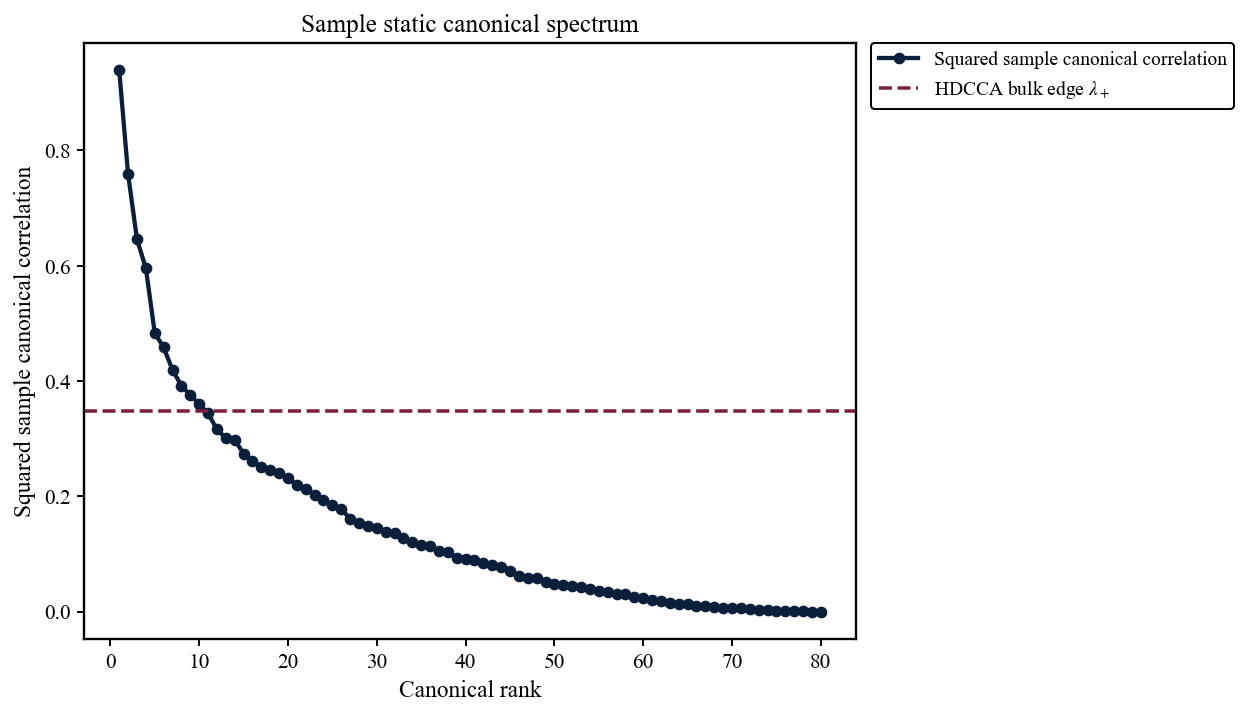

In [ ]:
X_full = X_main.to_numpy(dtype=float)
Y_full = Y_main.to_numpy(dtype=float)
X_full_c = X_full - X_full.mean(axis=0, keepdims=True)
Y_full_c = Y_full - Y_full.mean(axis=0, keepdims=True)

full_fit = cca_from_centered(X_full_c, Y_full_c, ridge=RIDGE_EPS)
full_lambda = full_fit["lambda_sq"]
full_lambda_plus = lambda_plus_hdcca(X_main.shape[1], Y_main.shape[1], len(X_main))
full_n_outliers = int(np.sum(full_lambda > full_lambda_plus))

full_static_table = pd.DataFrame({
    "rank": np.arange(1, len(full_lambda) + 1),
    "lambda_sq": full_lambda,
    "flag_outlier_above_bulk": full_lambda > full_lambda_plus,
})
full_static_table.to_csv(TABLE_DIR / "full_sample_static_spectrum.csv", index=False)

print(f"Full-sample lambda_+ = {full_lambda_plus:.6f}")
print(f"Full-sample outlier count = {full_n_outliers}")

fig, ax = thesis_figure(figsize=(8.8, 5.0))
ax.plot(
    full_static_table["rank"],
    full_static_table["lambda_sq"],
    marker="o",
    linewidth=2.2,
    markersize=5,
    color=THESIS_COLORS["navy"],
    label="Squared sample canonical correlation",
)
ax.axhline(
    full_lambda_plus,
    color=THESIS_COLORS["burgundy"],
    linestyle="--",
    linewidth=1.8,
    label=r"HDCCA bulk edge $\lambda_+$",
)
ax.set_title("Sample static canonical spectrum")
ax.set_xlabel("Canonical rank")
ax.set_ylabel("Squared sample canonical correlation")
style_axes(ax)
outside_legend(ax)
fig.savefig(FIG_DIR / "figure_full_sample_static_spectrum.png")
plt.show()

## 9. Run the main empirical specification

In [ ]:
rolling_summary_main, rolling_spectrum_main = run_rolling_analysis(
    X_df=X_main,
    Y_df=Y_main,
    window=main_spec["window"],
    step=main_spec["step"],
    n_perm=main_spec["n_perm"],
    label=main_spec["label"],
    ridge=RIDGE_EPS,
    n_components=N_COMPONENT_VECTOR_STAB,
    subspace_ks=SUBSPACE_KS,
    seed=SEED,
)
display(rolling_summary_main.head())

,window_id,start_date,end_date,n,p,q,lambda_plus,lambda1_sq,lambda2_sq,lambda3_sq,lambda4_sq,lambda5_sq,eigengap_12,eigengap_23,eigengap_34,n_outliers_above_bulk,flag_lead_outlier,perm_null_mean_lambda1_sq,perm_null_p95_lambda1_sq,perm_null_p99_lambda1_sq,credible_leading_window,implied_rho2_lead,pred_sin2_angle_x,pred_sin2_angle_y,pred_angle_x_deg,pred_angle_y_deg,split_stab_x_1,split_stab_x_2,split_stab_x_3,split_stab_x_4,split_stab_x_5,split_stab_y_1,split_stab_y_2,split_stab_y_3,split_stab_y_4,split_stab_y_5,subspace_overlap_x_top1,subspace_overlap_x_top2,subspace_overlap_x_top3,subspace_overlap_x_top5,subspace_overlap_y_top1,subspace_overlap_y_top2,subspace_overlap_y_top3,subspace_overlap_y_top5,split_oos_root_1,half1_lambda1_sq,half2_lambda1_sq
0,0,2010-01-08,2014-12-26,260,80,80,0.852071,0.975635,0.904045,0.850550,0.835966,0.820777,0.071590,0.053495,0.014584,2,1,0.839623,0.862885,0.871738,0,NaN,NaN,NaN,NaN,NaN,0.004914,0.041138,0.029462,0.001733,0.005067,0.001406,0.016883,0.038064,0.061182,0.001074,0.004914,0.026095,0.068625,0.078740,0.001406,0.031374,0.095845,0.190593,0.018485,1.0,1.0
1,1,2010-02-05,2015-01-23,260,80,80,0.852071,0.975313,0.894159,0.854239,0.829446,0.812832,0.081154,0.039919,0.024793,3,1,0.840172,0.863473,0.872165,0,NaN,NaN,NaN,NaN,NaN,0.035365,0.047086,0.029453,0.019470,0.029209,0.002233,0.002081,0.069375,0.019806,0.000699,0.035365,0.070694,0.080701,0.084768,0.002233,0.009099,0.070769,0.088239,0.007157,1.0,1.0
2,2,2010-03-05,2015-02-20,260,80,80,0.852071,0.975094,0.892385,0.850437,0.827738,0.808057,0.082709,0.041947,0.022699,2,1,0.840230,0.862953,0.869735,0,NaN,NaN,NaN,NaN,NaN,0.029245,0.012623,0.013644,0.001413,0.001284,0.058538,0.101586,0.000078,0.079620,0.009893,0.029245,0.049222,0.119933,0.119777,0.058538,0.110272,0.091366,0.116473,0.009429,1.0,1.0
3,3,2010-04-02,2015-03-20,260,80,80,0.852071,0.976080,0.898322,0.865556,0.829121,0.819829,0.077758,0.032766,0.036435,3,1,0.839997,0.862565,0.871035,0,NaN,NaN,NaN,NaN,NaN,0.006525,0.012089,0.002182,0.003839,0.078716,0.014544,0.058659,0.018797,0.006538,0.008105,0.006525,0.030957,0.029892,0.092763,0.014544,0.049774,0.056880,0.120513,0.000101,1.0,1.0
4,4,2010-04-30,2015-04-17,260,80,80,0.852071,0.975185,0.892144,0.861175,0.821283,0.816659,0.083040,0.030970,0.039892,3,1,0.840227,0.862682,0.873133,0,NaN,NaN,NaN,NaN,NaN,0.011079,0.030695,0.021099,0.027777,0.000894,0.007256,0.003768,0.000083,0.001932,0.017773,0.011079,0.021799,0.047744,0.089266,0.007256,0.011057,0.023683,0.093034,0.053757,1.0,1.0


## 10. Rolling-results master table

In [ ]:
rolling_summary_metrics = pd.DataFrame({
    "metric": [
        "n_windows",
        "mean_lambda1_sq",
        "median_lambda1_sq",
        "mean_lambda_plus",
        "share_lead_outlier",
        "mean_n_outliers_above_bulk",
        "mean_split_stab_x_1",
        "mean_split_stab_y_1",
        "mean_split_oos_root_1",
        "share_credible_leading_windows",
        "mean_subspace_overlap_x_top5",
        "mean_subspace_overlap_y_top5",
    ],
    "value": [
        len(rolling_summary_main),
        rolling_summary_main["lambda1_sq"].mean(),
        rolling_summary_main["lambda1_sq"].median(),
        rolling_summary_main["lambda_plus"].mean(),
        rolling_summary_main["flag_lead_outlier"].mean(),
        rolling_summary_main["n_outliers_above_bulk"].mean(),
        rolling_summary_main["split_stab_x_1"].mean(),
        rolling_summary_main["split_stab_y_1"].mean(),
        rolling_summary_main["split_oos_root_1"].mean(),
        rolling_summary_main["credible_leading_window"].mean(),
        rolling_summary_main["subspace_overlap_x_top5"].mean(),
        rolling_summary_main["subspace_overlap_y_top5"].mean(),
    ],
})
display(rolling_summary_metrics)
rolling_summary_metrics.to_csv(TABLE_DIR / "main_260w_rolling_summary_metrics.csv", index=False)

,metric,value
0,n_windows,144.000000
1,mean_lambda1_sq,0.973143
2,median_lambda1_sq,0.974703
3,mean_lambda_plus,0.852071
4,share_lead_outlier,1.000000
5,mean_n_outliers_above_bulk,4.173611
6,mean_split_stab_x_1,0.021921
7,mean_split_stab_y_1,0.032935
8,mean_split_oos_root_1,0.012829
9,share_credible_leading_windows,0.000000


Baseline empirical finding (main 260-week specification)

Across 144 rolling windows, the mean leading squared sample canonical correlation is
0.9731, versus a mean HDCCA bulk edge of
0.8521. The leading root exceeds the bulk edge in
100.0% of windows, and the mean number of outliers
above the bulk is 4.17.

At the same time, the first split-sample vector overlaps remain low:
X-side = 0.0219,
Y-side = 0.0329.

The held-out leading root is much smaller on average (0.0128),
which supports the interpretation that the spectrum contains persistent outliers but the leading canonical
portfolio is not stably estimated as an individual direction.


Baseline empirical finding (main 260-week specification):

Across 144 rolling windows, the mean leading squared sample canonical correlation is
0.9731, versus a mean HDCCA bulk edge of
0.8521. The leading root exceeds the bulk edge in
100.0% of windows, and the mean number of outliers
above the bulk is 4.17.

At the same time, the first split-sample vector overlaps remain low:
X-side = 0.0219,
Y-side = 0.0329.

The held-out leading root is much smaller on average (0.0128),
which supports the interpretation that the spectrum contains persistent outliers but the leading canonical
portfolio is not stably estimated as an individual direction.

## 11. Main rolling figures

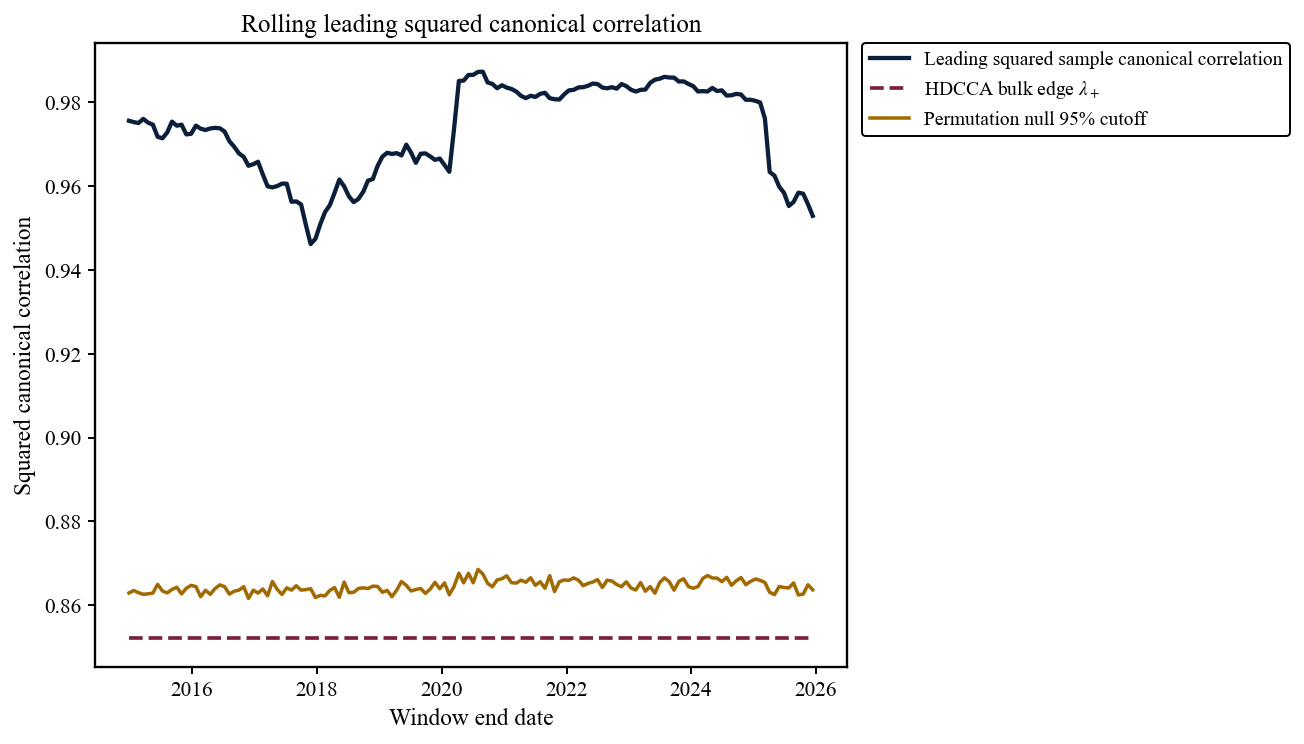

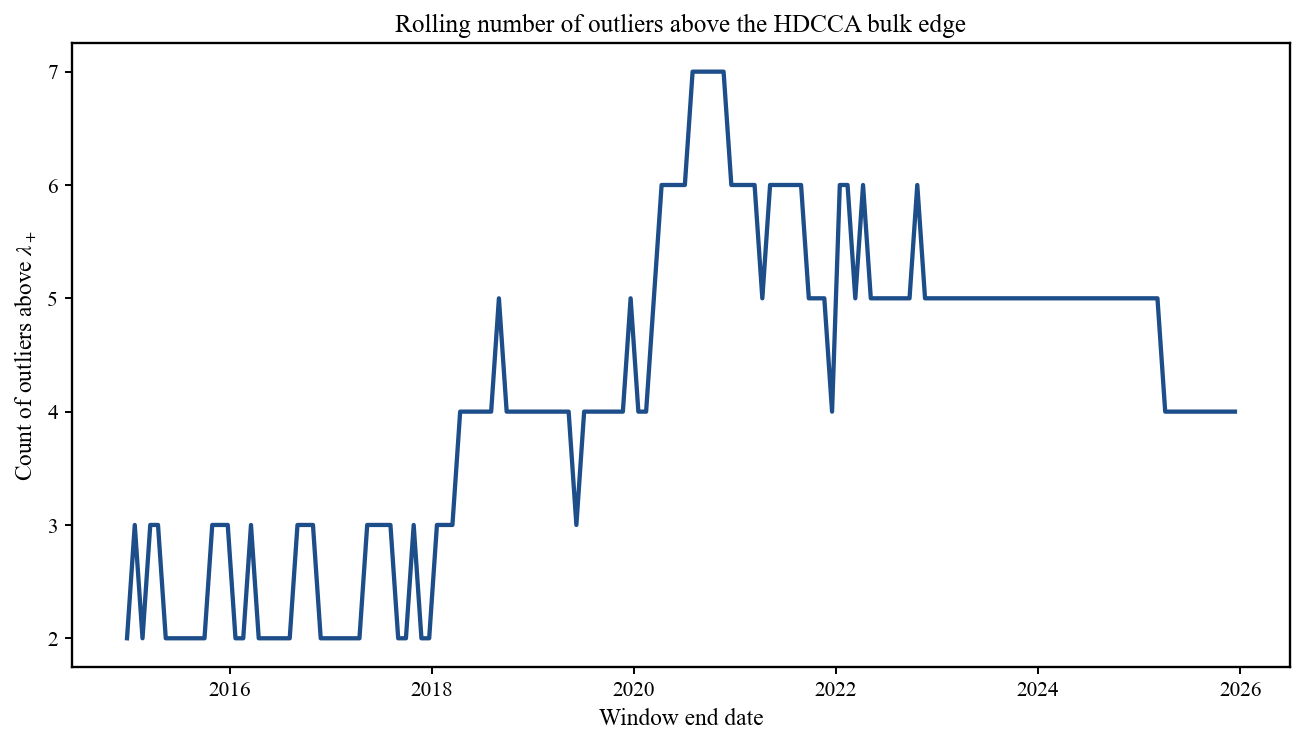

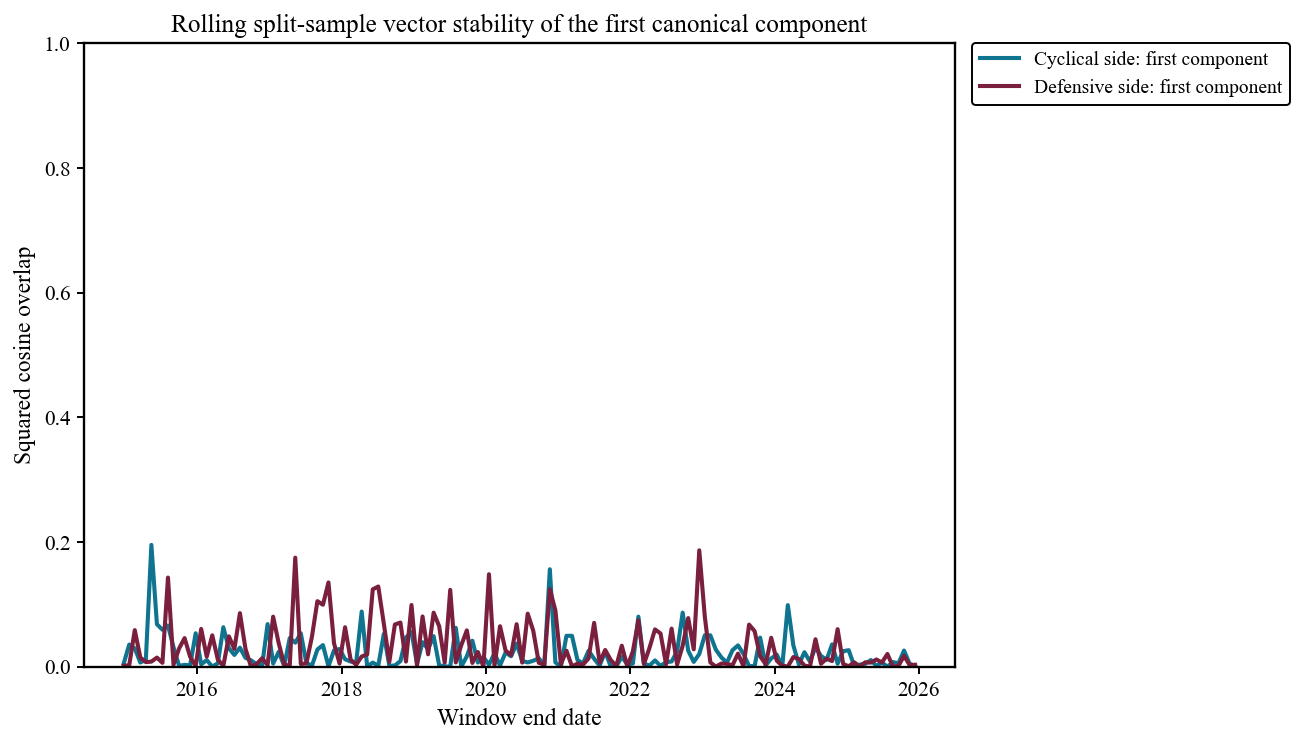

In [ ]:
# Figure 1: leading root vs bulk edge and permutation null
fig, ax = thesis_figure(figsize=(9.2, 5.2))
ax.plot(
    rolling_summary_main["end_date"],
    rolling_summary_main["lambda1_sq"],
    linewidth=2.2,
    color=THESIS_COLORS["navy"],
    label="Leading squared sample canonical correlation",
)
ax.plot(
    rolling_summary_main["end_date"],
    rolling_summary_main["lambda_plus"],
    linewidth=1.9,
    color=THESIS_COLORS["burgundy"],
    linestyle="--",
    label=r"HDCCA bulk edge $\lambda_+$",
)
ax.plot(
    rolling_summary_main["end_date"],
    rolling_summary_main["perm_null_p95_lambda1_sq"],
    linewidth=1.8,
    color=THESIS_COLORS["gold"],
    label="Permutation null 95% cutoff",
)
ax.set_title("Rolling leading squared canonical correlation")
ax.set_xlabel("Window end date")
ax.set_ylabel("Squared canonical correlation")
style_axes(ax)
outside_legend(ax)
fig.savefig(FIG_DIR / "figure1_leading_root_vs_bulk_and_null_main260.png")
plt.show()

# Figure 2: number of outliers above the bulk edge
fig, ax = thesis_figure(figsize=(9.2, 5.2))
ax.plot(
    rolling_summary_main["end_date"],
    rolling_summary_main["n_outliers_above_bulk"],
    linewidth=2.2,
    color=THESIS_COLORS["blue"],
)
ax.set_title("Rolling number of outliers above the HDCCA bulk edge")
ax.set_xlabel("Window end date")
ax.set_ylabel(r"Count of outliers above $\lambda_+$")
style_axes(ax)
fig.savefig(FIG_DIR / "figure2_outlier_count_main260.png")
plt.show()

# Figure 3: split-sample vector stability (first component)
fig, ax = thesis_figure(figsize=(9.2, 5.2))
ax.plot(
    rolling_summary_main["end_date"],
    rolling_summary_main["split_stab_x_1"],
    linewidth=2.1,
    color=THESIS_COLORS["teal"],
    label="Cyclical side: first component",
)
ax.plot(
    rolling_summary_main["end_date"],
    rolling_summary_main["split_stab_y_1"],
    linewidth=2.1,
    color=THESIS_COLORS["burgundy"],
    label="Defensive side: first component",
)
ax.set_title("Rolling split-sample vector stability of the first canonical component")
ax.set_xlabel("Window end date")
ax.set_ylabel("Squared cosine overlap")
ax.set_ylim(0, 1)
style_axes(ax)
outside_legend(ax)
fig.savefig(FIG_DIR / "figure3_split_sample_stability_component1_main260.png")
plt.show()

## 12. Top-k subspace stability and eigengaps

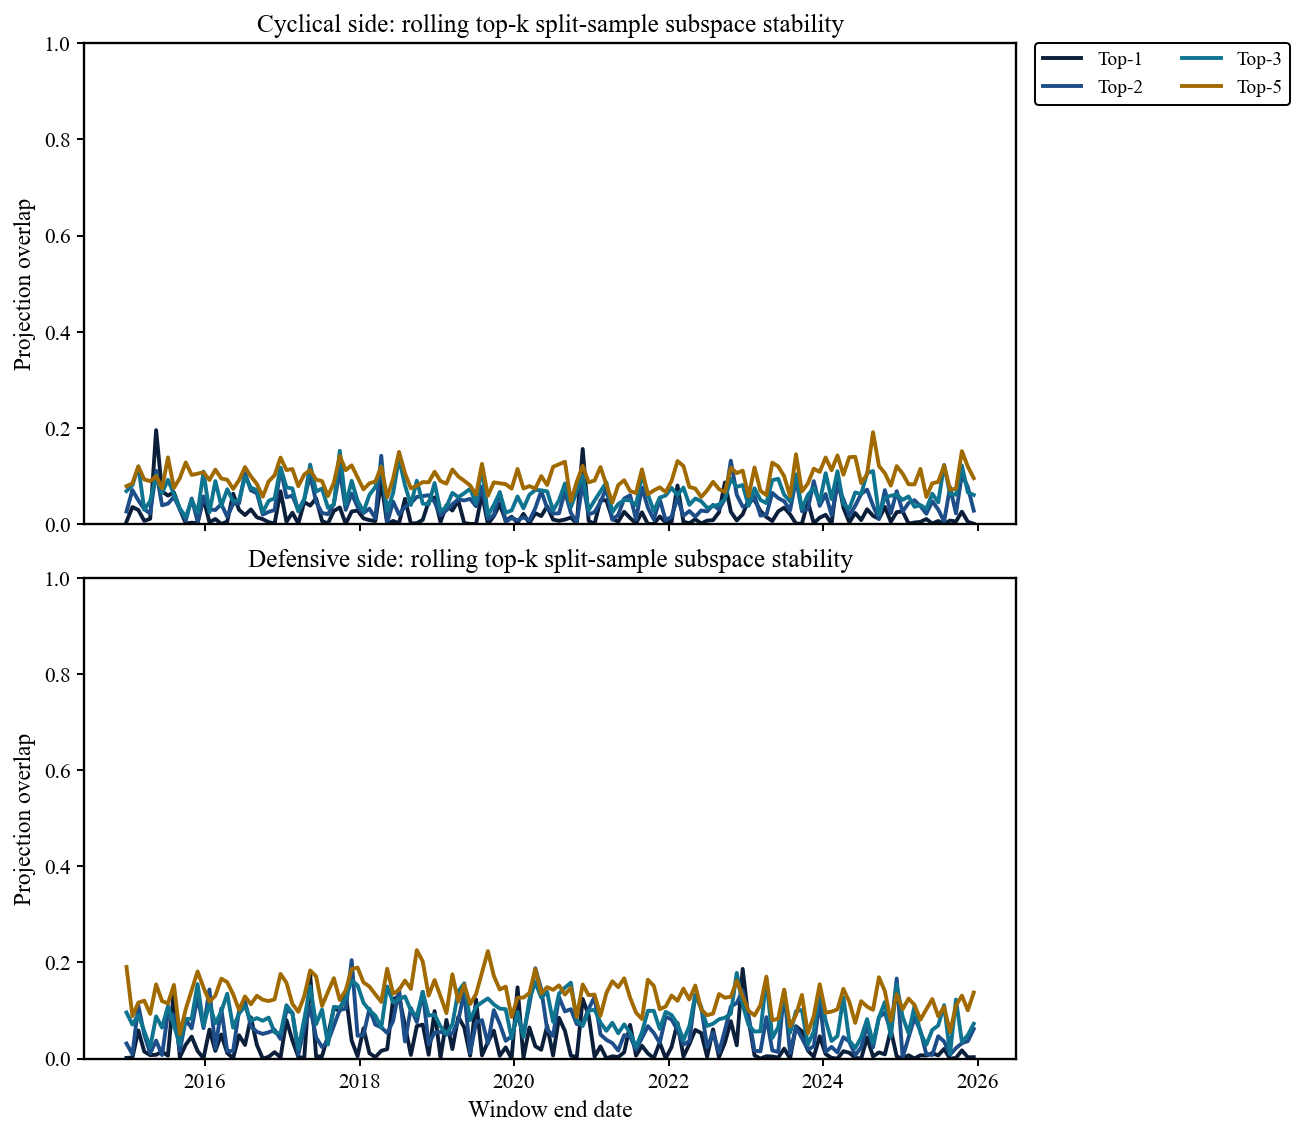

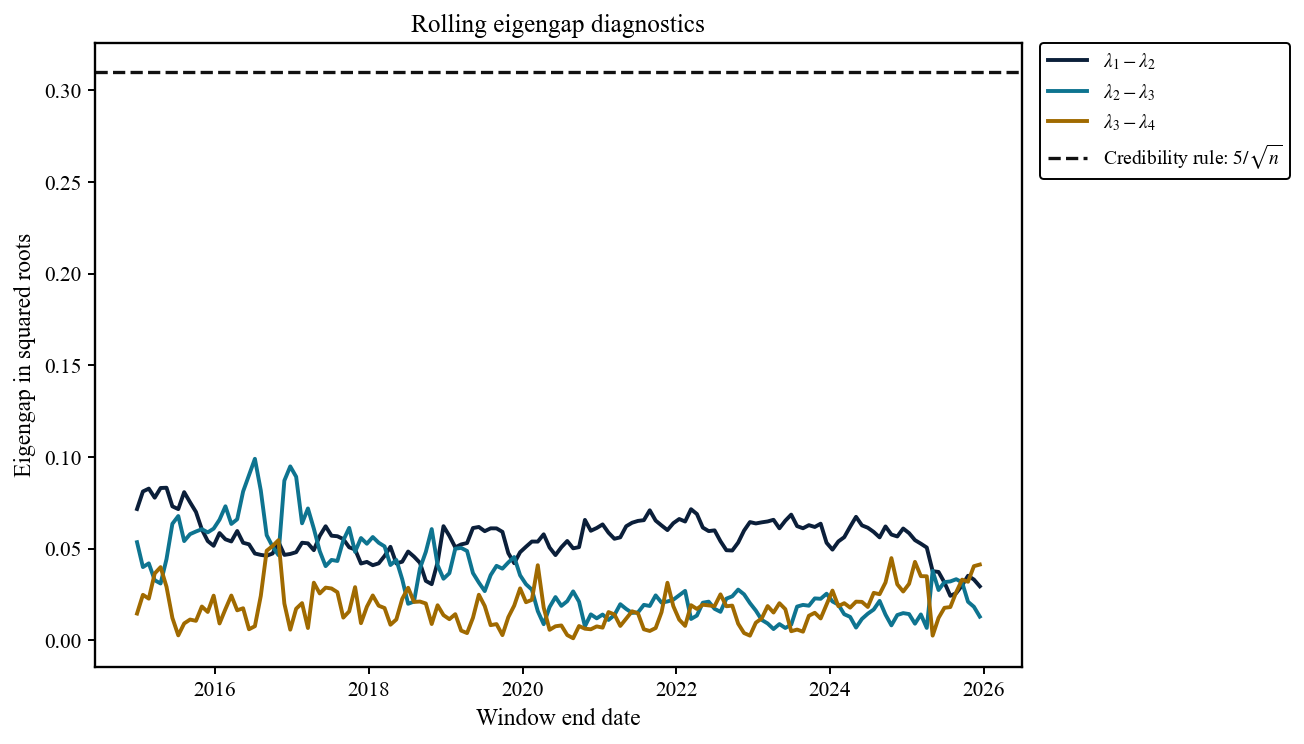

In [ ]:
fig, axes = thesis_subplots(2, 1, figsize=(9.2, 8.0), sharex=True)
palette = [
    THESIS_COLORS["navy"],
    THESIS_COLORS["blue"],
    THESIS_COLORS["teal"],
    THESIS_COLORS["gold"],
]

for color, k in zip(palette, SUBSPACE_KS):
    axes[0].plot(
        rolling_summary_main["end_date"],
        rolling_summary_main[f"subspace_overlap_x_top{k}"],
        linewidth=2.0,
        color=color,
        label=f"Top-{k}",
    )
axes[0].set_title("Cyclical side: rolling top-k split-sample subspace stability")
axes[0].set_ylabel("Projection overlap")
axes[0].set_ylim(0, 1)
style_axes(axes[0])
outside_legend(axes[0], ncol=2)

for color, k in zip(palette, SUBSPACE_KS):
    axes[1].plot(
        rolling_summary_main["end_date"],
        rolling_summary_main[f"subspace_overlap_y_top{k}"],
        linewidth=2.0,
        color=color,
        label=f"Top-{k}",
    )
axes[1].set_title("Defensive side: rolling top-k split-sample subspace stability")
axes[1].set_xlabel("Window end date")
axes[1].set_ylabel("Projection overlap")
axes[1].set_ylim(0, 1)
style_axes(axes[1])

fig.savefig(FIG_DIR / "figure4_topk_subspace_stability_main260.png")
plt.show()

fig, ax = thesis_figure(figsize=(9.2, 5.2))
ax.plot(
    rolling_summary_main["end_date"],
    rolling_summary_main["eigengap_12"],
    linewidth=2.0,
    color=THESIS_COLORS["navy"],
    label=r"$\lambda_1 - \lambda_2$",
)
ax.plot(
    rolling_summary_main["end_date"],
    rolling_summary_main["eigengap_23"],
    linewidth=2.0,
    color=THESIS_COLORS["teal"],
    label=r"$\lambda_2 - \lambda_3$",
)
ax.plot(
    rolling_summary_main["end_date"],
    rolling_summary_main["eigengap_34"],
    linewidth=2.0,
    color=THESIS_COLORS["gold"],
    label=r"$\lambda_3 - \lambda_4$",
)
ax.axhline(
    5.0 / np.sqrt(main_spec["window"]),
    color=THESIS_COLORS["charcoal"],
    linestyle="--",
    linewidth=1.7,
    label=r"Credibility rule: $5 / \sqrt{n}$",
)
ax.set_title("Rolling eigengap diagnostics")
ax.set_xlabel("Window end date")
ax.set_ylabel("Eigengap in squared roots")
style_axes(ax)
outside_legend(ax)
fig.savefig(FIG_DIR / "figure5_eigengap_diagnostics_main260.png")
plt.show()

## 13. Phase-transition diagnostics for credible leading windows only

Credible leading windows: 0 out of 144


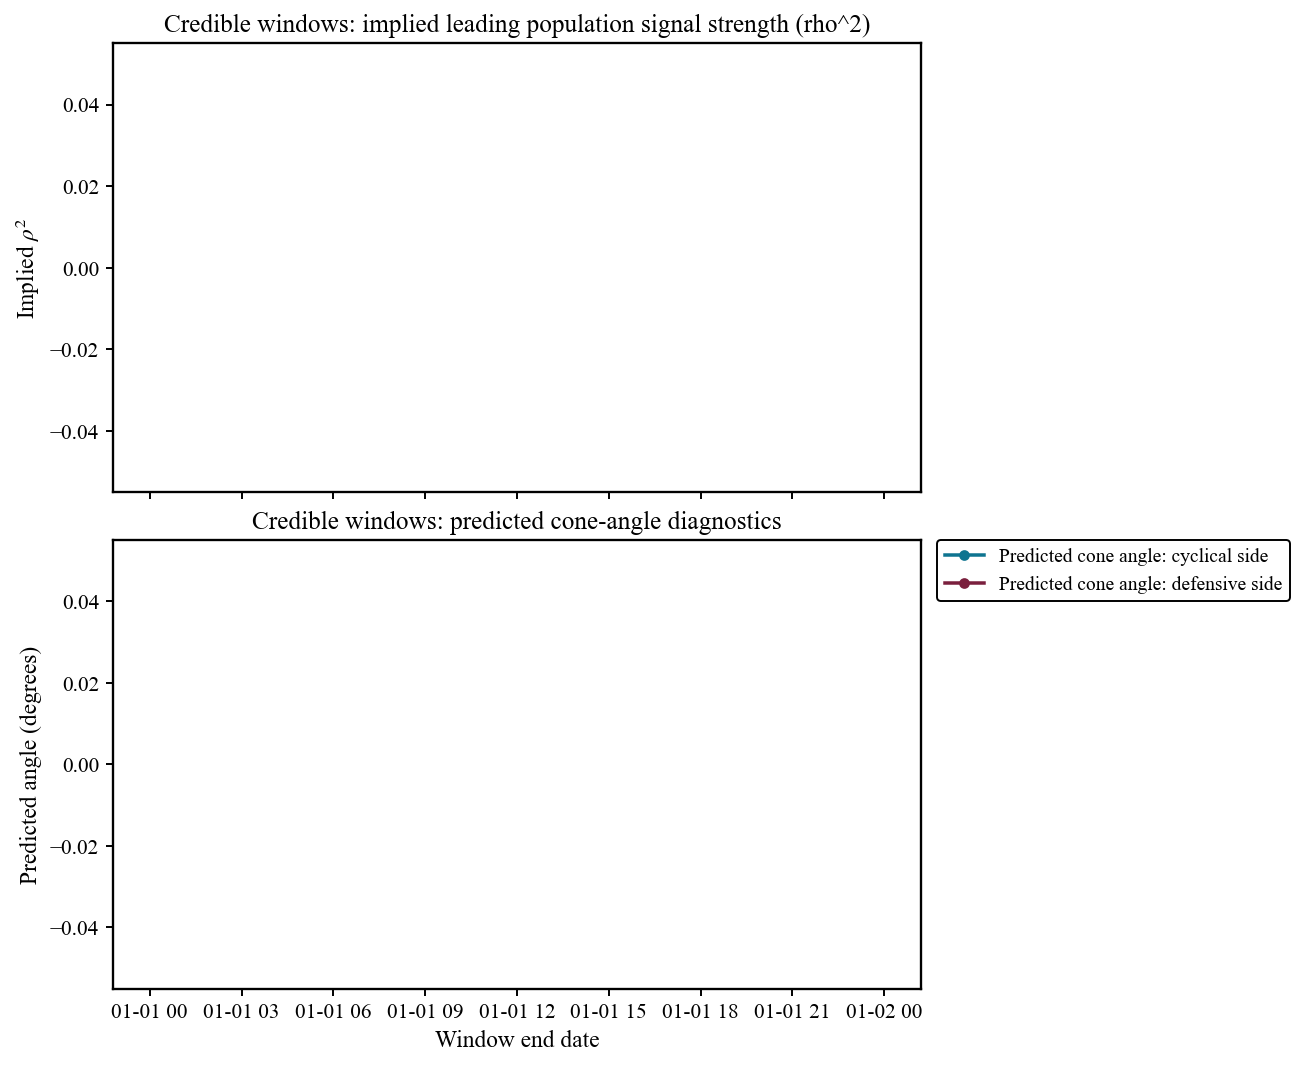

In [ ]:
credible_df = rolling_summary_main.loc[rolling_summary_main["credible_leading_window"] == 1].copy()
credible_df.to_csv(TABLE_DIR / "main_260w_credible_leading_windows.csv", index=False)

print(f"Credible leading windows: {len(credible_df)} out of {len(rolling_summary_main)}")

fig, axes = thesis_subplots(2, 1, figsize=(9.2, 7.5), sharex=True)

axes[0].plot(
    credible_df["end_date"],
    credible_df["implied_rho2_lead"],
    marker="o",
    markersize=4.5,
    linewidth=1.8,
    color=THESIS_COLORS["navy"],
)
axes[0].set_title("Credible windows: implied leading population signal strength (rho^2)")
axes[0].set_ylabel(r"Implied $\rho^2$")
style_axes(axes[0])

axes[1].plot(
    credible_df["end_date"],
    credible_df["pred_angle_x_deg"],
    marker="o",
    markersize=4.5,
    linewidth=1.8,
    color=THESIS_COLORS["teal"],
    label="Predicted cone angle: cyclical side",
)
axes[1].plot(
    credible_df["end_date"],
    credible_df["pred_angle_y_deg"],
    marker="o",
    markersize=4.5,
    linewidth=1.8,
    color=THESIS_COLORS["burgundy"],
    label="Predicted cone angle: defensive side",
)
axes[1].set_title("Credible windows: predicted cone-angle diagnostics")
axes[1].set_xlabel("Window end date")
axes[1].set_ylabel("Predicted angle (degrees)")
style_axes(axes[1])
outside_legend(axes[1])

fig.savefig(FIG_DIR / "figure6_phase_transition_diagnostics_main260.png")
plt.show()

## 14. Out-of-sample validation block

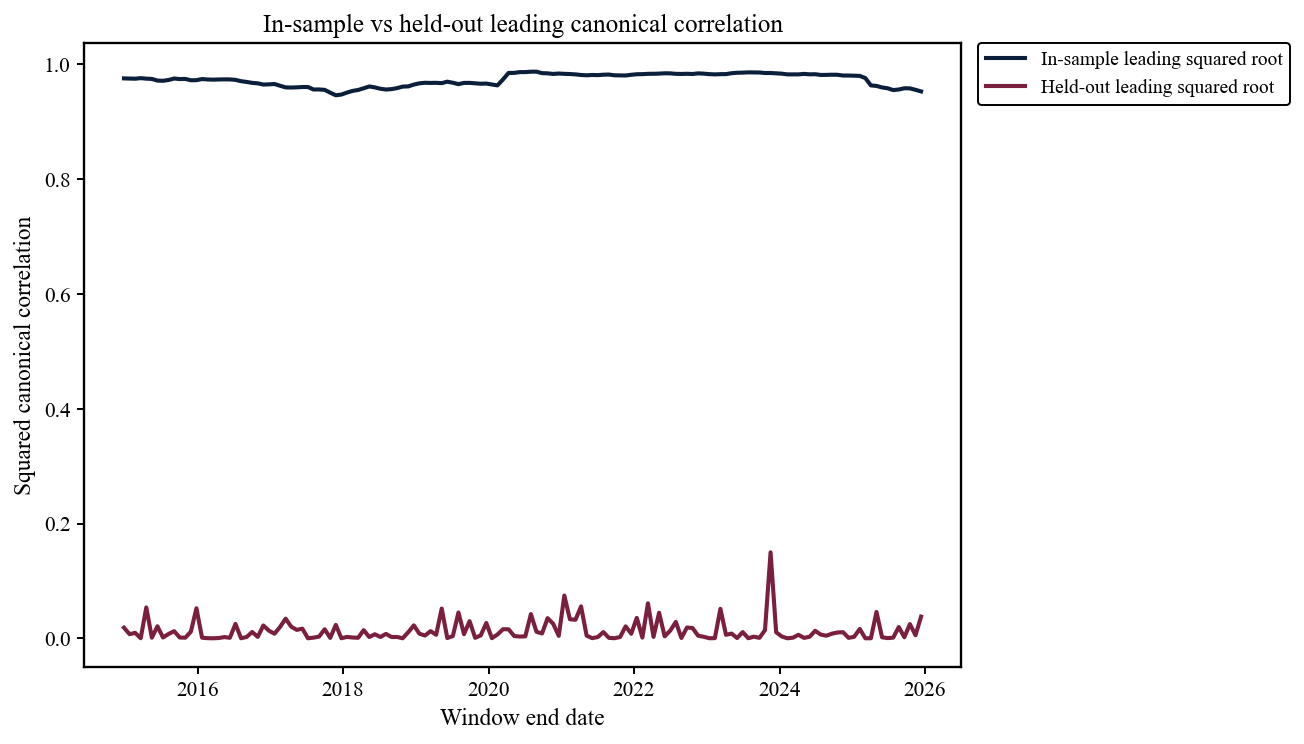

In [ ]:
fig, ax = thesis_figure(figsize=(9.2, 5.2))
ax.plot(
    rolling_summary_main["end_date"],
    rolling_summary_main["lambda1_sq"],
    linewidth=2.1,
    color=THESIS_COLORS["navy"],
    label="In-sample leading squared root",
)
ax.plot(
    rolling_summary_main["end_date"],
    rolling_summary_main["split_oos_root_1"],
    linewidth=2.1,
    color=THESIS_COLORS["burgundy"],
    label="Held-out leading squared root",
)
ax.set_title("In-sample vs held-out leading canonical correlation")
ax.set_xlabel("Window end date")
ax.set_ylabel("Squared canonical correlation")
style_axes(ax)
outside_legend(ax)
fig.savefig(FIG_DIR / "figure7_insample_vs_heldout_main260.png")
plt.show()

## 15. Robustness runs

In [ ]:
all_results = {"main_260w": rolling_summary_main}
all_spectra = {"main_260w": rolling_spectrum_main}

for spec in ANALYSIS_SPECS[1:]:
    X_spec, Y_spec = sample_slice(X, Y, spec["sample"])
    summary_i, spectrum_i = run_rolling_analysis(
        X_df=X_spec,
        Y_df=Y_spec,
        window=spec["window"],
        step=spec["step"],
        n_perm=spec["n_perm"],
        label=spec["label"],
        ridge=RIDGE_EPS,
        n_components=N_COMPONENT_VECTOR_STAB,
        subspace_ks=SUBSPACE_KS,
        seed=SEED,
    )
    all_results[spec["label"]] = summary_i
    all_spectra[spec["label"]] = spectrum_i

robust_rows = []
for spec in ANALYSIS_SPECS:
    df = all_results[spec["label"]]
    robust_rows.append({
        "label": spec["label"],
        "sample": spec["sample"],
        "window": spec["window"],
        "step": spec["step"],
        "n_perm": spec["n_perm"],
        "n_windows": len(df),
        "mean_lambda1_sq": df["lambda1_sq"].mean(),
        "mean_lambda_plus": df["lambda_plus"].mean(),
        "share_lead_outlier": df["flag_lead_outlier"].mean(),
        "mean_n_outliers_above_bulk": df["n_outliers_above_bulk"].mean(),
        "mean_split_stab_x_1": df["split_stab_x_1"].mean(),
        "mean_split_stab_y_1": df["split_stab_y_1"].mean(),
        "mean_split_oos_root_1": df["split_oos_root_1"].mean(),
        "mean_subspace_overlap_x_top5": df["subspace_overlap_x_top5"].mean(),
        "mean_subspace_overlap_y_top5": df["subspace_overlap_y_top5"].mean(),
        "share_credible_leading_windows": df["credible_leading_window"].mean(),
    })

robustness_summary = pd.DataFrame(robust_rows)
display(robustness_summary)
robustness_summary.to_csv(TABLE_DIR / "robustness_summary_across_specs.csv", index=False)

,label,sample,window,step,n_perm,n_windows,mean_lambda1_sq,mean_lambda_plus,share_lead_outlier,mean_n_outliers_above_bulk,mean_split_stab_x_1,mean_split_stab_y_1,mean_split_oos_root_1,mean_subspace_overlap_x_top5,mean_subspace_overlap_y_top5,share_credible_leading_windows
0,main_260w,full,260,4,1000,144,0.973143,0.852071,1.0,4.173611,0.021921,0.032935,0.012829,0.095836,0.129725,0.0
1,robust_208w,full,208,4,500,157,0.983909,0.946746,1.0,2.815287,0.026299,0.028186,0.020493,0.099136,0.124379,0.0
2,robust_364w,full,364,4,500,118,0.961194,0.685907,1.0,6.135593,0.029076,0.019292,0.338480,0.099518,0.094488,0.0
3,pre2020_260w,pre2020,260,4,500,66,0.965700,0.852071,1.0,2.984848,0.025311,0.039925,0.010820,0.095341,0.141517,0.0
4,post2020_260w,post2020,260,4,500,13,0.963779,0.852071,1.0,4.230769,0.019209,0.023572,0.017084,0.103127,0.099999,0.0


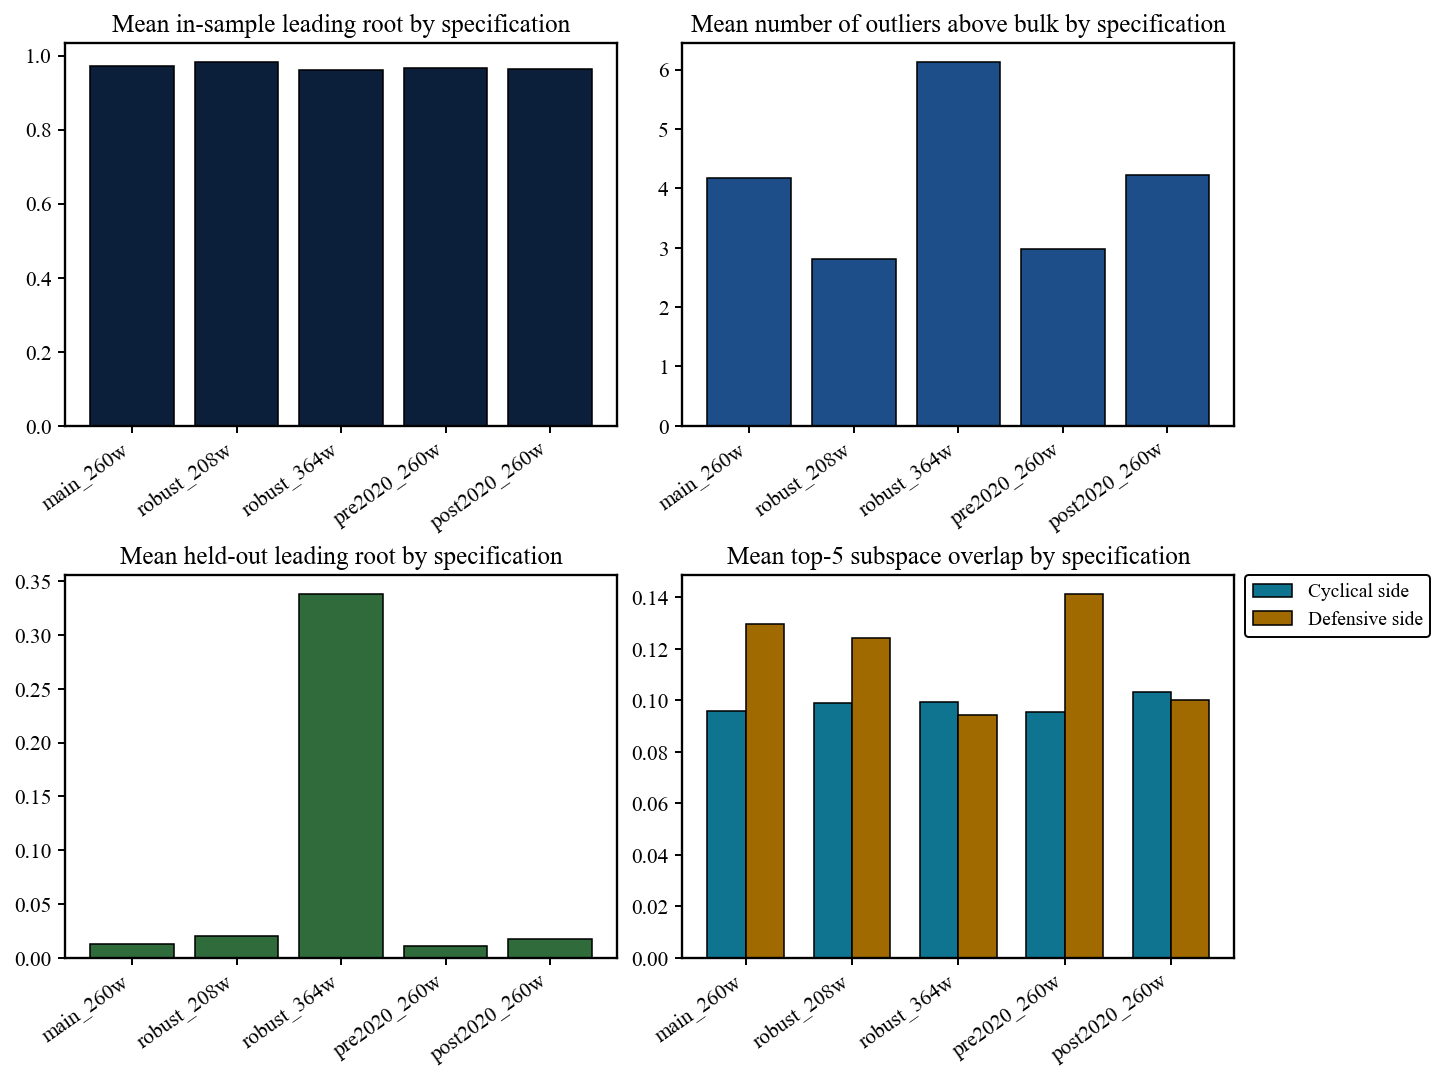

In [ ]:
fig, axes = thesis_subplots(2, 2, figsize=(10.2, 7.6))
labels = robustness_summary["label"]

axes[0,0].bar(labels, robustness_summary["mean_lambda1_sq"], color=THESIS_COLORS["navy"], edgecolor="black", linewidth=0.8)
axes[0,0].set_title("Mean in-sample leading root by specification")
style_axes(axes[0,0])
rotate_xlabels(axes[0,0])

axes[0,1].bar(labels, robustness_summary["mean_n_outliers_above_bulk"], color=THESIS_COLORS["blue"], edgecolor="black", linewidth=0.8)
axes[0,1].set_title("Mean number of outliers above bulk by specification")
style_axes(axes[0,1])
rotate_xlabels(axes[0,1])

axes[1,0].bar(labels, robustness_summary["mean_split_oos_root_1"], color=THESIS_COLORS["green"], edgecolor="black", linewidth=0.8)
axes[1,0].set_title("Mean held-out leading root by specification")
style_axes(axes[1,0])
rotate_xlabels(axes[1,0])

width = 0.36
x = np.arange(len(labels))
axes[1,1].bar(
    x - width / 2,
    robustness_summary["mean_subspace_overlap_x_top5"],
    width=width,
    color=THESIS_COLORS["teal"],
    edgecolor="black",
    linewidth=0.8,
    label="Cyclical side",
)
axes[1,1].bar(
    x + width / 2,
    robustness_summary["mean_subspace_overlap_y_top5"],
    width=width,
    color=THESIS_COLORS["gold"],
    edgecolor="black",
    linewidth=0.8,
    label="Defensive side",
)
axes[1,1].set_xticks(x, labels)
axes[1,1].set_title("Mean top-5 subspace overlap by specification")
style_axes(axes[1,1])
rotate_xlabels(axes[1,1])
outside_legend(axes[1,1])

fig.savefig(FIG_DIR / "figure8_robustness_summary_across_specs.png")
plt.show()

## 16. Final exported objects

In [ ]:
print("Saved clean data:")
for p in sorted(DATA_DIR.glob("*")):
    print(" -", p.name)

print("\nSaved tables:")
for p in sorted(TABLE_DIR.glob("*.csv")):
    print(" -", p.name)
for p in sorted(TABLE_DIR.glob("*.txt")):
    print(" -", p.name)

print("\nSaved figures:")
for p in sorted(FIG_DIR.glob("*.png")):
    print(" -", p.name)

Saved clean data:
 - returns_weekly_clean_crsp.csv
 - stock_metadata_clean_crsp.csv
 - weekly_long_selected_universe_crsp.csv

Saved tables:
 - baseline_sample_summary.csv
 - crsp_candidate_security_stats.csv
 - crsp_preselection_summary.csv
 - crsp_selected_bucket_sector_mix.csv
 - crsp_selected_panel_summary.csv
 - crsp_selection_trials.csv
 - full_sample_static_spectrum.csv
 - main_260w_credible_leading_windows.csv
 - main_260w_rolling_results_master_table.csv
 - main_260w_rolling_spectra_long.csv
 - main_260w_rolling_summary_metrics.csv
 - post2020_260w_rolling_results_master_table.csv
 - post2020_260w_rolling_spectra_long.csv
 - pre2020_260w_rolling_results_master_table.csv
 - pre2020_260w_rolling_spectra_long.csv
 - robust_208w_rolling_results_master_table.csv
 - robust_208w_rolling_spectra_long.csv
 - robust_364w_rolling_results_master_table.csv
 - robust_364w_rolling_spectra_long.csv
 - robustness_summary_across_specs.csv
 - baseline_written_finding.txt

Saved figures:
 - figur